In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/products.csv
/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/order_products__train.csv
/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/orders.csv
/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/order_products__prior.csv
/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/aisles.csv
/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/departments.csv


In [2]:
import torch
import torch.nn as nn

# T4 x2 — use both GPUs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"GPUs available: {torch.cuda.device_count()}")
print(f"GPU 0: {torch.cuda.get_device_name(0)}")
print(f"GPU 1: {torch.cuda.get_device_name(1)}")

GPUs available: 2
GPU 0: Tesla T4
GPU 1: Tesla T4


In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
import warnings
warnings.filterwarnings("ignore")

In [4]:
aisles = pd.read_csv("/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/aisles.csv")
aisles

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation
...,...,...
129,130,hot cereal pancake mixes
130,131,dry pasta
131,132,beauty
132,133,muscles joints pain relief


In [5]:
departments = pd.read_csv("/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/departments.csv")
departments

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol
5,6,international
6,7,beverages
7,8,pets
8,9,dry goods pasta
9,10,bulk


In [6]:
orders = pd.read_csv("/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/orders.csv")
orders

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0
...,...,...,...,...,...,...,...
3421078,2266710,206209,prior,10,5,18,29.0
3421079,1854736,206209,prior,11,4,10,30.0
3421080,626363,206209,prior,12,1,12,18.0
3421081,2977660,206209,prior,13,1,12,7.0


In [9]:
products = pd.read_csv("/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/products.csv")
products

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
...,...,...,...,...
49683,49684,"Vodka, Triple Distilled, Twist of Vanilla",124,5
49684,49685,En Croute Roast Hazelnut Cranberry,42,1
49685,49686,Artisan Baguette,112,3
49686,49687,Smartblend Healthy Metabolism Dry Cat Food,41,8


In [7]:
prior = pd.read_csv("/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/order_products__prior.csv")
train = pd.read_csv("/kaggle/input/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/order_products__train.csv")
order_products = pd.concat([prior, train], ignore_index=True)
order_products

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0
...,...,...,...,...
33819101,3421063,14233,3,1
33819102,3421063,35548,4,1
33819103,3421070,35951,1,1
33819104,3421070,16953,2,1


In [10]:
print(f"Orders:         {orders.shape}")
print(f"Order products: {order_products.shape}")
print(f"Products:       {products.shape}")

Orders:         (3421083, 7)
Order products: (33819106, 4)
Products:       (49688, 4)


In [11]:
# ─────────────────────────────────────────────
# STEP 2 — BUILD USER SEQUENCES
# ─────────────────────────────────────────────
# Goal: for each user, get a list of items they ordered in order
# e.g. user 1 → [banana, milk, eggs, yogurt, bread, ...]

print("\nBuilding user sequences...")

# Merge to get user_id and order timing into the product table
op = order_products.merge(
    orders[["order_id", "user_id", "order_number", "order_hour_of_day", "order_dow"]],
    on="order_id"
)
op.head(15)


Building user sequences...


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_hour_of_day,order_dow
0,2,33120,1,1,202279,3,9,5
1,2,28985,2,1,202279,3,9,5
2,2,9327,3,0,202279,3,9,5
3,2,45918,4,1,202279,3,9,5
4,2,30035,5,0,202279,3,9,5
5,2,17794,6,1,202279,3,9,5
6,2,40141,7,1,202279,3,9,5
7,2,1819,8,1,202279,3,9,5
8,2,43668,9,0,202279,3,9,5
9,3,33754,1,1,205970,16,17,5


In [12]:
# Remove very rare items (ordered fewer than 50 times across all users)
# Rare items don't have enough signal to learn from
item_counts = op["product_id"].value_counts()
item_counts


product_id
24852    491291
13176    394930
21137    275577
21903    251705
47209    220877
          ...  
37703         1
43725         1
36233         1
18001         1
32464         1
Name: count, Length: 49685, dtype: int64

In [13]:
popular_items = item_counts[item_counts >= 50].index
op = op[op["product_id"].isin(popular_items)]
print(f"Items after filtering rare ones: {op['product_id'].nunique():,}")

Items after filtering rare ones: 27,208


In [14]:
# Remove users with very few orders (need at least 5 items to learn a pattern)
user_counts = op.groupby("user_id")["order_id"].nunique()
active_users = user_counts[user_counts >= 5].index
op = op[op["user_id"].isin(active_users)]
print(f"Users after filtering: {op['user_id'].nunique():,}")

Users after filtering: 174,942


In [15]:
# Build item vocabulary — map each product_id to a small integer
# 0 is reserved for padding
all_items = op["product_id"].unique()
item2id = {item: idx + 1 for idx, item in enumerate(all_items)}
id2item = {idx: item for item, idx in item2id.items()}
NUM_ITEMS = len(item2id) + 1   # +1 for the padding token (0)
print(f"Vocabulary size: {NUM_ITEMS:,}")

op["item_id"] = op["product_id"].map(item2id)

# Sort by user → order number → cart order to get chronological sequence
op = op.sort_values(["user_id", "order_number", "add_to_cart_order"])

# For each user, collect their item sequence and context (hour, day)
user_sequences = {}

for user_id, group in op.groupby("user_id"):
    user_sequences[user_id] = {
        "items": group["item_id"].tolist(),
        "hours": group["order_hour_of_day"].tolist(),
        "dows":  group["order_dow"].tolist(),
    }

print(f"Total users with sequences: {len(user_sequences):,}")

Vocabulary size: 27,209
Total users with sequences: 174,942


In [16]:
# Peek at one user's sequence
sample_user = list(user_sequences.keys())[0]
sample_seq  = user_sequences[sample_user]["items"]
print(f"\nExample — user {sample_user}:")
print(f"  Sequence length: {len(sample_seq)}")
print(f"  First 10 items:  {sample_seq[:10]}")


Example — user 1:
  Sequence length: 70
  First 10 items:  [108, 1181, 3751, 2190, 10038, 108, 2412, 3751, 31, 2190]


In [18]:
# ─────────────────────────────────────────────
# STEP 3 — DATASET CLASS
# ─────────────────────────────────────────────
# This is what feeds data into the model during training
#
# For each user we create one sample:
#   input  = all items except the last one
#   target = the last item  ← what the model must predict
#
# We pad the input on the LEFT so all sequences are the same length

MAX_SEQ_LEN = 50   # truncate/pad all sequences to this length

def pad_sequence(seq, max_len, pad_value=0):
    """Left-pad a sequence to max_len. Truncate from left if too long."""
    seq = seq[-max_len:]                        # keep only the last max_len items
    pad = [pad_value] * (max_len - len(seq))    # how many zeros to add
    return pad + seq                            # zeros on the LEFT


In [20]:
class FoodDataset(Dataset):

    def __init__(self, user_sequences):
        self.samples = []

        for user_id, data in user_sequences.items():
            items = data["items"]
            hours = data["hours"]
            dows  = data["dows"]

            # Need at least 2 items (1 input + 1 target)
            if len(items) < 2:
                continue

            # input  = everything except the last item
            # target = the last item
            input_items = items[:-1]
            target      = items[-1]
            input_hours = hours[:-1]
            input_dows  = dows[:-1]

            self.samples.append({
                "input_items": pad_sequence(input_items, MAX_SEQ_LEN),
                "input_hours": pad_sequence(input_hours, MAX_SEQ_LEN),
                "input_dows":  pad_sequence(input_dows,  MAX_SEQ_LEN),
                "target":      target,
            })

        print(f"Total training samples: {len(self.samples):,}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return {
            "input_items": torch.tensor(s["input_items"], dtype=torch.long),
            "input_hours": torch.tensor(s["input_hours"], dtype=torch.long),
            "input_dows":  torch.tensor(s["input_dows"],  dtype=torch.long),
            "target":      torch.tensor(s["target"],      dtype=torch.long),
        }



In [22]:
# ─────────────────────────────────────────────
# STEP 4 — TRAIN / VAL SPLIT
# ─────────────────────────────────────────────
# Simple 80/20 split on users

all_user_ids = list(user_sequences.keys())
np.random.shuffle(all_user_ids)

split        = int(0.8 * len(all_user_ids))
train_users  = {uid: user_sequences[uid] for uid in all_user_ids[:split]}
val_users    = {uid: user_sequences[uid] for uid in all_user_ids[split:]}

train_dataset = FoodDataset(train_users)
val_dataset   = FoodDataset(val_users)

train_loader  = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=256, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Total training samples: 139,953
Total training samples: 34,989

Train batches: 547
Val batches:   137


In [23]:
# ─────────────────────────────────────────────
# STEP 5 — THE TRANSFORMER MODEL
# ─────────────────────────────────────────────
#
# Architecture:
#
#  item_id ──→ [Item Embedding]  ─┐
#  hour    ──→ [Hour Embedding]  ─┼──→ ADD ──→ [Transformer Layers] ──→ [Linear] ──→ scores over all items
#  dow     ──→ [DOW  Embedding]  ─┘
#
# The transformer learns: given this sequence of items (+ when they were ordered),
# what item is most likely to come next?

class FoodRecommender(nn.Module):

    def __init__(self, num_items, hidden_dim=64, num_heads=2, num_layers=2, dropout=0.3):
        super().__init__()

        # ── Embeddings ──────────────────────────────────────
        # Each item gets a 64-dim vector the model learns
        self.item_embedding = nn.Embedding(num_items, hidden_dim, padding_idx=0)

        # Hour of day: 0–23 → one vector each
        self.hour_embedding = nn.Embedding(25, hidden_dim, padding_idx=0)

        # Day of week: 0–6 → one vector each
        self.dow_embedding  = nn.Embedding(8,  hidden_dim, padding_idx=0)

        # Position: tells the model "this is the 1st item, 2nd item, ..."
        self.pos_embedding  = nn.Embedding(MAX_SEQ_LEN, hidden_dim)

        # ── Transformer ─────────────────────────────────────
        # num_heads=2: attention looks at 2 different "aspects" at once
        # num_layers=2: two stacked transformer blocks
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dropout=dropout,
            batch_first=True,    # input shape: (batch, seq_len, hidden_dim)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # ── Output layer ────────────────────────────────────
        # Takes the transformer's output and scores every item in the vocabulary
        self.output = nn.Linear(hidden_dim, num_items)

        self.dropout = nn.Dropout(dropout)

    def forward(self, item_seq, hour_seq, dow_seq):
        """
        item_seq : (batch_size, seq_len)  — item IDs
        hour_seq : (batch_size, seq_len)  — hour of each order
        dow_seq  : (batch_size, seq_len)  — day of week of each order

        Returns:
        logits   : (batch_size, num_items) — score for each item being next
        """
        batch_size, seq_len = item_seq.shape

        # ── Build position tensor ────────────────────────────
        # [0, 1, 2, ..., seq_len-1] for each item in the sequence
        positions = torch.arange(seq_len, device=item_seq.device)
        positions = positions.unsqueeze(0).expand(batch_size, -1)  # (batch, seq_len)

        # ── Combine all embeddings ───────────────────────────
        # Each embedding is (batch, seq_len, hidden_dim)
        # Add them all together → one rich vector per position
        x = (
            self.item_embedding(item_seq) +
            self.hour_embedding(hour_seq) +
            self.dow_embedding(dow_seq)   +
            self.pos_embedding(positions)
        )
        x = self.dropout(x)

        # ── Padding mask ─────────────────────────────────────
        # Tell the transformer to ignore padded positions (item_id == 0)
        padding_mask = (item_seq == 0)   # True where padded

        # ── Transformer forward pass ─────────────────────────
        x = self.transformer(x, src_key_padding_mask=padding_mask)
        # x shape: (batch, seq_len, hidden_dim)

        # ── Take the LAST position's hidden state ────────────
        # The last real position summarizes the whole sequence
        # → use it to predict the next item
        x = x[:, -1, :]   # (batch, hidden_dim)

        # ── Score every item ─────────────────────────────────
        logits = self.output(x)   # (batch, num_items)

        return logits

In [24]:
# ─────────────────────────────────────────────
# STEP 6 — TRAINING LOOP
# ─────────────────────────────────────────────

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS     = 10
LR         = 1e-3

print(f"\nUsing device: {DEVICE}")

model     = FoodRecommender(num_items=NUM_ITEMS).to(DEVICE)
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)   # ignore padding token in loss

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for batch in loader:
        input_items = batch["input_items"].to(DEVICE)
        input_hours = batch["input_hours"].to(DEVICE)
        input_dows  = batch["input_dows"].to(DEVICE)
        target      = batch["target"].to(DEVICE)

        optimizer.zero_grad()

        # Forward pass → scores for every item
        logits = model(input_items, input_hours, input_dows)
        # logits shape: (batch, NUM_ITEMS)
        # target shape: (batch,)

        loss = criterion(logits, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, criterion, k=10):
    """
    Compute loss, Hit Rate@K and NDCG@K on val set.

    Hit Rate@K  : did the correct item appear in the top K predictions?
    NDCG@K      : like hit rate but rewards ranking the correct item higher
    """
    model.eval()
    total_loss = 0
    hits, ndcg_scores = 0, 0

    with torch.no_grad():
        for batch in loader:
            input_items = batch["input_items"].to(DEVICE)
            input_hours = batch["input_hours"].to(DEVICE)
            input_dows  = batch["input_dows"].to(DEVICE)
            target      = batch["target"].to(DEVICE)

            logits = model(input_items, input_hours, input_dows)
            loss   = criterion(logits, target)
            total_loss += loss.item()

            # Get top K predicted items for each user in batch
            topk = torch.topk(logits, k, dim=1).indices   # (batch, k)

            for i in range(len(target)):
                true_item = target[i].item()
                top_items = topk[i].tolist()

                if true_item in top_items:
                    hits += 1
                    # NDCG rewards items ranked closer to position 1
                    rank = top_items.index(true_item) + 1
                    ndcg_scores += 1 / np.log2(rank + 1)

    n = len(loader.dataset)
    return {
        "loss":   total_loss / len(loader),
        "hit@10": hits / n,
        "ndcg@10": ndcg_scores / n,
    }



Using device: cuda


In [25]:
# ── Run training ────────────────────────────────────────────
print("\nStarting training...\n")
history = {"train_loss": [], "val_loss": [], "hit10": [], "ndcg10": []}

# ── Early stopping config ────────────────────────────────────
PATIENCE       = 3        # stop if val loss doesn't improve for 3 epochs
best_val_loss  = float("inf")
patience_count = 0
best_model_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_metrics = evaluate(model, val_loader, criterion)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["hit10"].append(val_metrics["hit@10"])
    history["ndcg10"].append(val_metrics["ndcg@10"])
    print(f"Epoch {epoch:02d}/{EPOCHS}  |  "
          f"Train Loss: {train_loss:.4f}  |  "
          f"Val Loss: {val_metrics['loss']:.4f}  |  "
          f"Hit@10: {val_metrics['hit@10']:.4f}  |  "
          f"NDCG@10: {val_metrics['ndcg@10']:.4f}")
    # ── Early stopping check ─────────────────────────────────
    if val_metrics["loss"] < best_val_loss:
        best_val_loss    = val_metrics["loss"]
        patience_count   = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  ✓ New best val loss: {best_val_loss:.4f} — saving checkpoint")
    else:
        patience_count += 1
        print(f"  No improvement ({patience_count}/{PATIENCE})")
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break
# Restore best weights
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nRestored best model (val loss: {best_val_loss:.4f})")


Starting training...

Epoch 01/10  |  Train Loss: 9.1757  |  Val Loss: 9.0336  |  Hit@10: 0.0552  |  NDCG@10: 0.0282
  ✓ New best val loss: 9.0336 — saving checkpoint
Epoch 02/10  |  Train Loss: 8.9984  |  Val Loss: 8.8997  |  Hit@10: 0.0621  |  NDCG@10: 0.0328
  ✓ New best val loss: 8.8997 — saving checkpoint
Epoch 03/10  |  Train Loss: 8.7844  |  Val Loss: 8.7027  |  Hit@10: 0.0622  |  NDCG@10: 0.0339
  ✓ New best val loss: 8.7027 — saving checkpoint
Epoch 04/10  |  Train Loss: 8.6228  |  Val Loss: 8.6465  |  Hit@10: 0.0666  |  NDCG@10: 0.0364
  ✓ New best val loss: 8.6465 — saving checkpoint
Epoch 05/10  |  Train Loss: 8.5452  |  Val Loss: 8.6317  |  Hit@10: 0.0680  |  NDCG@10: 0.0375
  ✓ New best val loss: 8.6317 — saving checkpoint
Epoch 06/10  |  Train Loss: 8.4615  |  Val Loss: 8.6477  |  Hit@10: 0.0687  |  NDCG@10: 0.0366
  No improvement (1/3)
Epoch 07/10  |  Train Loss: 8.3598  |  Val Loss: 8.6776  |  Hit@10: 0.0668  |  NDCG@10: 0.0363
  No improvement (2/3)
Epoch 08/10  |  

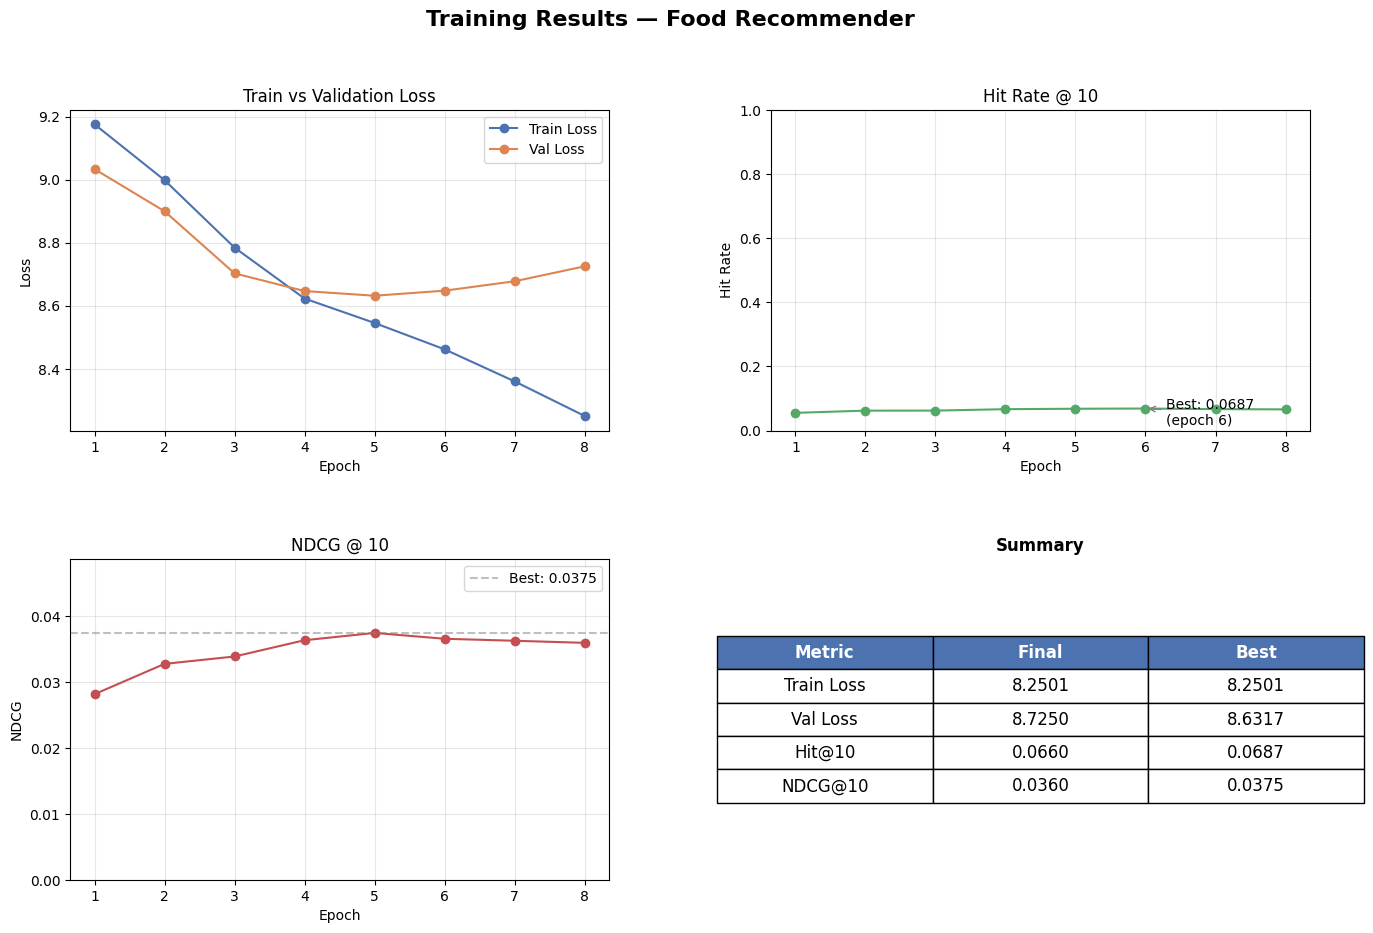

Plot saved → /kaggle/working/training_results.png


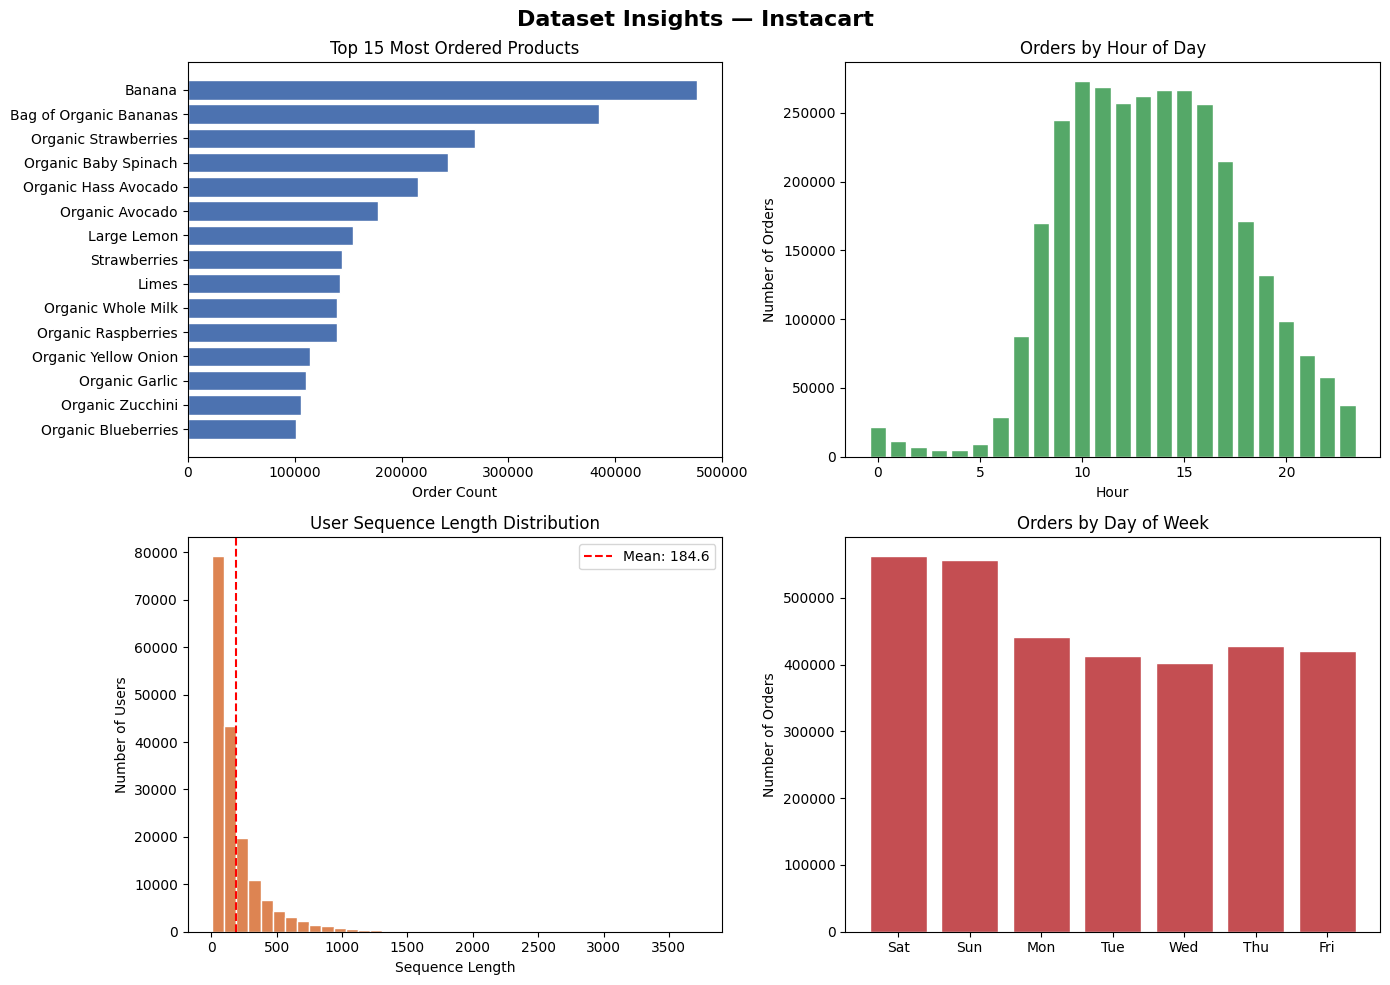

Plot saved → /kaggle/working/data_insights.png


In [26]:
def plot_training(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle("Training Results — Food Recommender", fontsize=16, fontweight="bold")
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

    # ── Plot 1: Train vs Val Loss ────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, history["train_loss"], "o-", color="#4C72B0", label="Train Loss")
    ax1.plot(epochs, history["val_loss"],   "o-", color="#DD8452", label="Val Loss")
    ax1.set_title("Train vs Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # ── Plot 2: Hit Rate@10 ──────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, history["hit10"], "o-", color="#55A868")
    ax2.set_title("Hit Rate @ 10")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Hit Rate")
    ax2.set_ylim(0, 1)
    ax2.grid(alpha=0.3)
    # Annotate best epoch
    best_epoch = int(np.argmax(history["hit10"])) + 1
    best_hit   = max(history["hit10"])
    ax2.annotate(f"Best: {best_hit:.4f}\n(epoch {best_epoch})",
                 xy=(best_epoch, best_hit),
                 xytext=(best_epoch + 0.3, best_hit - 0.05),
                 arrowprops=dict(arrowstyle="->", color="gray"))

    # ── Plot 3: NDCG@10 ─────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(epochs, history["ndcg10"], "o-", color="#C44E52")
    ax3.set_title("NDCG @ 10")
    ax3.set_xlabel("Epoch")
    ax3.set_ylabel("NDCG")
    ax3.set_ylim(0, max(history["ndcg10"]) * 1.3)
    ax3.grid(alpha=0.3)
    best_ndcg = max(history["ndcg10"])
    ax3.axhline(best_ndcg, linestyle="--", color="gray", alpha=0.5, label=f"Best: {best_ndcg:.4f}")
    ax3.legend()

    # ── Plot 4: Summary table ────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis("off")
    summary_data = [
        ["Metric",        "Final",                              "Best"],
        ["Train Loss",    f"{history['train_loss'][-1]:.4f}",  f"{min(history['train_loss']):.4f}"],
        ["Val Loss",      f"{history['val_loss'][-1]:.4f}",    f"{min(history['val_loss']):.4f}"],
        ["Hit@10",        f"{history['hit10'][-1]:.4f}",       f"{max(history['hit10']):.4f}"],
        ["NDCG@10",       f"{history['ndcg10'][-1]:.4f}",      f"{max(history['ndcg10']):.4f}"],
    ]
    table = ax4.table(cellText=summary_data[1:], colLabels=summary_data[0],
                      loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 2)
    # Header row styling
    for j in range(3):
        table[0, j].set_facecolor("#4C72B0")
        table[0, j].set_text_props(color="white", fontweight="bold")
    ax4.set_title("Summary", fontweight="bold")

    plt.savefig("/kaggle/working/training_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved → /kaggle/working/training_results.png")

plot_training(history)


# ═══════════════════════════════════════════════════════════
# CELL 3 — DATA INSIGHT PLOTS
# ═══════════════════════════════════════════════════════════

def plot_data_insights(op, products):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Dataset Insights — Instacart", fontsize=16, fontweight="bold")

    # ── Top 15 most recommended products ────────────────────
    top_items = (
        op["item_id"].value_counts()
        .head(15)
        .reset_index()
        .rename(columns={"item_id": "item_id", "count": "count"})
    )
    top_items = top_items.merge(
        op[["item_id", "product_id"]].drop_duplicates(), on="item_id"
    ).merge(products[["product_id", "product_name"]], on="product_id")

    axes[0, 0].barh(top_items["product_name"], top_items["count"],
                    color="#4C72B0", edgecolor="white")
    axes[0, 0].invert_yaxis()
    axes[0, 0].set_title("Top 15 Most Ordered Products")
    axes[0, 0].set_xlabel("Order Count")

    # ── Orders by hour of day ────────────────────────────────
    hour_counts = op.groupby("order_hour_of_day")["order_id"].nunique()
    axes[0, 1].bar(hour_counts.index, hour_counts.values,
                   color="#55A868", edgecolor="white")
    axes[0, 1].set_title("Orders by Hour of Day")
    axes[0, 1].set_xlabel("Hour")
    axes[0, 1].set_ylabel("Number of Orders")

    # ── Sequence length distribution ─────────────────────────
    seq_lengths = [len(v["items"]) for v in user_sequences.values()]
    axes[1, 0].hist(seq_lengths, bins=40, color="#DD8452", edgecolor="white")
    axes[1, 0].axvline(np.mean(seq_lengths), color="red", linestyle="--",
                       label=f"Mean: {np.mean(seq_lengths):.1f}")
    axes[1, 0].set_title("User Sequence Length Distribution")
    axes[1, 0].set_xlabel("Sequence Length")
    axes[1, 0].set_ylabel("Number of Users")
    axes[1, 0].legend()

    # ── Orders by day of week ────────────────────────────────
    dow_map    = {0: "Sat", 1: "Sun", 2: "Mon", 3: "Tue", 4: "Wed", 5: "Thu", 6: "Fri"}
    dow_counts = op.groupby("order_dow")["order_id"].nunique()
    axes[1, 1].bar([dow_map[i] for i in dow_counts.index], dow_counts.values,
                   color="#C44E52", edgecolor="white")
    axes[1, 1].set_title("Orders by Day of Week")
    axes[1, 1].set_ylabel("Number of Orders")

    plt.tight_layout()
    plt.savefig("/kaggle/working/data_insights.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved → /kaggle/working/data_insights.png")

plot_data_insights(op, products)

In [27]:

# ── Save model ──────────────────────────────────────────────
torch.save({
    "model_state": model.state_dict(),
    "item2id":     item2id,
    "id2item":     id2item,
    "num_items":   NUM_ITEMS,
}, "/kaggle/working/food_recommender.pt")

print("\nModel saved to /kaggle/working/food_recommender.pt")


Model saved to /kaggle/working/food_recommender.pt


In [28]:

# ─────────────────────────────────────────────
# STEP 7 — MAKE A RECOMMENDATION
# ─────────────────────────────────────────────
# Given a user's past items, predict what they'll order next

def recommend(past_item_ids, past_hours, past_dows, top_k=10):
    """
    past_item_ids : list of item IDs the user ordered (chronological)
    past_hours    : list of hours for each order
    past_dows     : list of days of week for each order
    top_k         : how many recommendations to return
    """
    model.eval()
    with torch.no_grad():
        # Pad and convert to tensors
        items = torch.tensor([pad_sequence(past_item_ids, MAX_SEQ_LEN)], dtype=torch.long).to(DEVICE)
        hours = torch.tensor([pad_sequence(past_hours,    MAX_SEQ_LEN)], dtype=torch.long).to(DEVICE)
        dows  = torch.tensor([pad_sequence(past_dows,     MAX_SEQ_LEN)], dtype=torch.long).to(DEVICE)

        logits = model(items, hours, dows)
        top_ids = torch.topk(logits, top_k, dim=1).indices[0].tolist()

    # Decode item IDs back to product names
    recommendations = []
    for item_id in top_ids:
        product_id   = id2item.get(item_id)
        product_name = products[products["product_id"] == product_id]["product_name"].values
        recommendations.append(product_name[0] if len(product_name) else f"item_{item_id}")

    return recommendations


# Example prediction using the sample user from earlier
print("\n--- Example Recommendation ---")
sample_data  = user_sequences[sample_user]
past_items   = sample_data["items"][:-1]
past_hours   = sample_data["hours"][:-1]
past_dows    = sample_data["dows"][:-1]
true_next    = sample_data["items"][-1]

recs = recommend(past_items, past_hours, past_dows)
true_name = products[products["product_id"] == id2item.get(true_next)]["product_name"].values
print(f"True next item:    {true_name[0] if len(true_name) else true_next}")
print(f"Top 10 recommendations:")
for i, r in enumerate(recs, 1):
    print(f"  {i:>2}. {r}")



--- Example Recommendation ---
True next item:    Zero Calorie Cola
Top 10 recommendations:
   1. Soda
   2. Trail Mix
   3. Clementines
   4. Zero Calorie Cola
   5. Crunchy Oats 'n Honey Granola Bars
   6. Drinking Water
   7. Pub Mix
   8. 0% Greek Strained Yogurt
   9. Popcorn
  10. Mineral Water


In [29]:
# ═══════════════════════════════════════════════════════════
# CELL 1 — NAME → ID TRANSLATION
# ═══════════════════════════════════════════════════════════
# In your app, users will pass product names like "Banana"
# This cell converts names → item IDs → recommendations → names back

# Build a name lookup table (run this once after loading data)
name2id = {}
for _, row in products.iterrows():
    product_id = row["product_id"]
    name       = row["product_name"].strip().lower()   # lowercase for fuzzy matching
    if product_id in item2id:                          # only items in our vocabulary
        name2id[name] = item2id[product_id]

print(f"Products in lookup table: {len(name2id):,}")

Products in lookup table: 27,166


In [31]:

def names_to_ids(product_names):
    """
    Convert a list of product name strings to item IDs.
    Does case-insensitive exact matching first,
    then falls back to partial matching if no exact match found.

    Args:
        product_names : list of strings e.g. ["Banana", "Whole Milk", "Eggs"]

    Returns:
        matched_ids   : list of valid item IDs (skips unrecognized names)
        unmatched     : list of names that couldn't be matched
    """
    matched_ids = []
    unmatched   = []

    for name in product_names:
        name_lower = name.strip().lower()

        # ── Try exact match first ──────────────────────────
        if name_lower in name2id:
            matched_ids.append(name2id[name_lower])
            continue

        # ── Try partial match (name is substring of a product) ──
        partial_matches = [
            (product_name, item_id)
            for product_name, item_id in name2id.items()
            if name_lower in product_name
        ]

        if partial_matches:
            # Pick the shortest match (most specific)
            best_match = min(partial_matches, key=lambda x: len(x[0]))
            matched_ids.append(best_match[1])
            print(f"  '{name}' → matched to '{best_match[0]}'")
        else:
            unmatched.append(name)
            print(f"  '{name}' → not found in vocabulary, skipping")

    return matched_ids, unmatched


def recommend_from_names(product_names, hours=None, dows=None, top_k=10):
    """
    Full pipeline: product names → recommendations as product names.
    This is what your FastAPI endpoint will call.

    Args:
        product_names : list of strings — user's order history by name
        hours         : list of ints (0-23), one per product. Uses 12 if not provided.
        dows          : list of ints (0-6),  one per product. Uses 0 if not provided.
        top_k         : number of recommendations to return

    Returns:
        list of recommended product name strings

    Example:
        recommend_from_names(["Banana", "Whole Milk", "Eggs"])
    """
    # Convert names to IDs
    item_ids, unmatched = names_to_ids(product_names)

    if len(item_ids) == 0:
        print("No valid items found. Check your product names.")
        return []

    # Default context if not provided
    if hours is None:
        hours = [12] * len(item_ids)
    if dows is None:
        dows = [0] * len(item_ids)

    # Trim context to match filtered item_ids length
    # (some items may have been skipped in name matching)
    hours = hours[:len(item_ids)]
    dows  = dows[:len(item_ids)]

    # Get recommendations
    recs = recommend(item_ids, hours, dows, top_k=top_k)
    return recs

In [32]:
# ── Test it ─────────────────────────────────────────────────
print("\n--- Test: exact names ---")
test_names = ["Banana", "Whole Milk", "Organic Eggs"]
recs = recommend_from_names(test_names)
print("Recommendations:")
for i, r in enumerate(recs, 1):
    print(f"  {i:>2}. {r}")

print("\n--- Test: partial / messy names ---")
test_names_messy = ["banana", "milk", "eggs", "some product that doesnt exist"]
recs2 = recommend_from_names(test_names_messy)
print("Recommendations:")
for i, r in enumerate(recs2, 1):
    print(f"  {i:>2}. {r}")

print("\n--- Test: with time context (dinner time, Friday) ---")
test_names_ctx = ["Chicken", "Olive Oil", "Garlic"]
recs3 = recommend_from_names(
    test_names_ctx,
    hours=[18, 18, 18],   # 6pm
    dows= [6,  6,  6 ],   # Friday
)
print("Recommendations:")
for i, r in enumerate(recs3, 1):
    print(f"  {i:>2}. {r}")



--- Test: exact names ---
Recommendations:
   1. Banana
   2. Large Lemon
   3. 2% Reduced Fat Milk
   4. Strawberries
   5. 100% Whole Wheat Bread
   6. Limes
   7. Cola
   8. Purified Water
   9. Spinach
  10. Clementines, Bag

--- Test: partial / messy names ---
  'some product that doesnt exist' → not found in vocabulary, skipping
Recommendations:
   1. Banana
   2. Large Lemon
   3. Strawberries
   4. 2% Reduced Fat Milk
   5. Limes
   6. 100% Whole Wheat Bread
   7. Roma Tomato
   8. Organic Avocado
   9. Spinach
  10. Clementines, Bag

--- Test: with time context (dinner time, Friday) ---
Recommendations:
   1. Banana
   2. Strawberries
   3. Blueberries
   4. Vine Ripe Tomatoes
   5. Large Lemon
   6. 100% Whole Wheat Bread
   7. Limes
   8. Original Whipped Cream Cheese
   9. Original No Pulp 100% Florida Orange Juice
  10. Sparkling Natural Mineral Water


In [33]:
import json

# Save the name → id mapping
with open("/kaggle/working/name2id.json", "w") as f:
    json.dump(name2id, f)

# Save id → product name mapping (for decoding recommendations)
id2name = {str(item_id): name for name, item_id in name2id.items()}
with open("/kaggle/working/id2name.json", "w") as f:
    json.dump(id2name, f)

print(f"Saved name2id.json  ({len(name2id):,} products)")
print(f"Saved id2name.json  ({len(id2name):,} products)")

Saved name2id.json  (27,166 products)
Saved id2name.json  (27,166 products)
